In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Task
Transform the `retail` DataFrame to have years as columns and locations as rows.

## Clean and prepare the data

### Subtask:
Remove any unnecessary characters or rows and set appropriate column names.


**Reasoning**:
Based on the previous attempts where the DataFrame was empty, I need to reload the data with `header=None` to correctly parse the rows. Then I will split the single column using the semicolon delimiter.



### Process Retail Prices Data

In [19]:
### CLEAN PSA DATA
retail = pd.read_csv('../data/raw/psa_ube_data/retail_prices.csv', header=1)
retail.columns = retail.columns.str.replace(' Annual', '')
retail = retail.set_index('Geolocation')
# remove 'Commodity' column
retail = retail.drop(columns=['Commodity'])
retail


,2018,2019,2020,2021,2022,2023,2024,2025
Geolocation,,,,,,,,
PHILIPPINES,59.56,56.08,57.28,63.81,63.32,68.77,73.8,80.11


In [20]:
# make a list of years in the retail dataset
years = retail.columns.tolist()
years

['2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

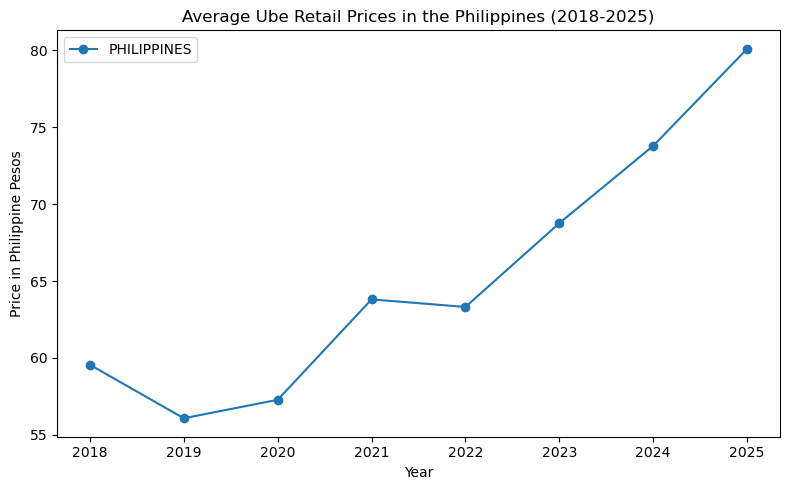

In [24]:
# philippines only

philippines = retail.loc['PHILIPPINES', years].astype(float)

plt.figure(figsize=(8, 5))
plt.plot(years, philippines, marker='o', label='PHILIPPINES')
plt.xlabel('Year')
plt.ylabel('Price in Philippine Pesos')
plt.title('Average Ube Retail Prices in the Philippines (2018-2025)')
plt.legend()
plt.tight_layout()
plt.savefig('heatmap.svg', bbox_inches='tight')
plt.show()

### Process Production Prices Data

In [37]:
production = pd.read_csv('../data/raw/psa_ube_data/production_metric_tons.csv', header=1)
production

,Crop,Geolocation,2010 Annual,2011 Annual,2012 Annual,2013 Annual,2014 Annual,2015 Annual,2016 Annual,2017 Annual,2018 Annual,2019 Annual,2020 Annual,2021 Annual,2022 Annual,2023 Annual,2024 Annual,2025 Annual
0,Ubi [Greater yam],PHILIPPINES,21906.13,17844.09,16428.91,14770.39,15245.23,13797.61,14165.87,14375.53,14464.83,14037.74,13957.61,14150.62,13534.87,12869.0,13381.52,12483.31


In [38]:
### CLEAN PSA DATA
production.columns = production.columns.str.replace(' Annual', '')
production = production.set_index('Geolocation')
# remove 'Commodity' column
production = production.drop(columns=['Crop'])
production

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Geolocation,,,,,,,,,,,,,,,,
PHILIPPINES,21906.13,17844.09,16428.91,14770.39,15245.23,13797.61,14165.87,14375.53,14464.83,14037.74,13957.61,14150.62,13534.87,12869.0,13381.52,12483.31


## Plot combination of retail price and production

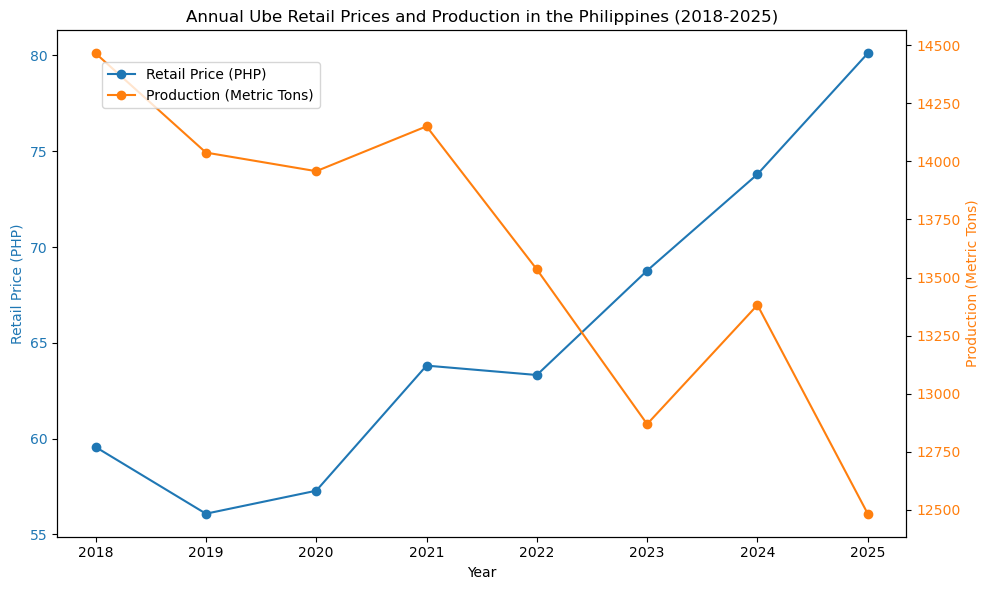

In [43]:
# create joint line plot for annual retail prices of ube and annual production of ube in the philippines with one y-axis for retail prices and another y-axis for production
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(years, philippines, marker='o', color='C0', label='Retail Price (PHP)')
ax2.plot(years, production.loc['PHILIPPINES', years].astype(float), marker='o', color='C1', label='Production (Metric Tons)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Retail Price (PHP)', color='C0')
ax2.set_ylabel('Production (Metric Tons)', color='C1')
ax1.tick_params(axis='y', labelcolor='C0')
ax2.tick_params(axis='y', labelcolor='C1')
plt.title('Annual Ube Retail Prices and Production in the Philippines (2018-2025)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()

# save the plot as a png file
plt.savefig('../output/ube_retail_production.png', bbox_inches='tight', dpi=300)

plt.show()

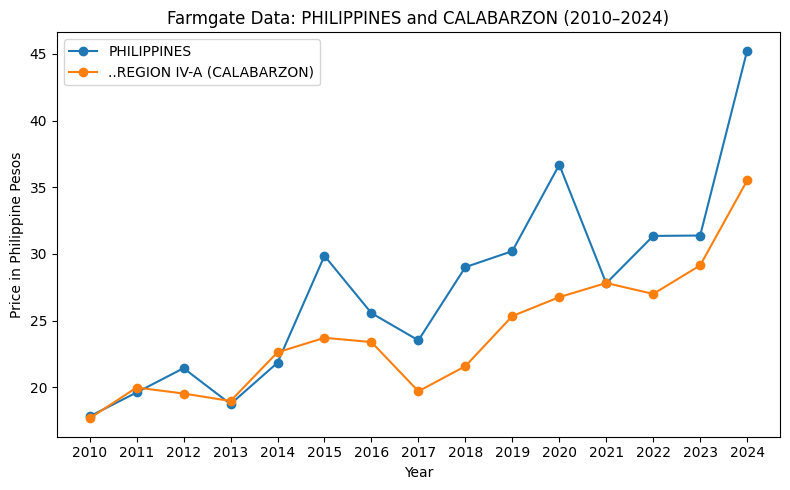

In [ ]:
# create line plot for annual retail prices of ube. Make one line for the Philippines and one for calabarzon

philippines = retail.loc['PRODUCTION', years].astype(float)
calabarzon = retail.loc['', years].astype(float)

plt.figure(figsize=(8, 5))
plt.plot(years, philippines, marker='o', label='PHILIPPINES')
plt.plot(years, calabarzon, marker='o', label='..REGION IV-A (CALABARZON)')
plt.xlabel('Year')
plt.ylabel('Price in Philippine Pesos')
plt.title('Retail Data: PHILIPPINES and CALABARZON (2010–2024)')
plt.legend()
plt.tight_layout()
plt.show()